Stress level prediction

EDA

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [57]:
df = pd.read_csv('stress_detection_data.csv')
df.head()

,Age,Gender,Occupation,Marital_Status,Sleep_Duration,Sleep_Quality,Wake_Up_Time,Bed_Time,Physical_Activity,Screen_Time,...,Smoking_Habit,Work_Hours,Travel_Time,Social_Interactions,Meditation_Practice,Exercise_Type,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level,Stress_Detection
0,30,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,No,8,1.0,5,Yes,Cardio,120,180,90,Low
1,35,Female,Marketing Manager,Married,6.0,3.0,6:00 AM,11:00 PM,1.0,3.0,...,No,9,2.0,3,No,Yoga,110,160,80,Medium
2,40,Male,Data Scientist,Divorced,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,No,8,1.0,5,Yes,Strength Training,130,200,100,High
3,35,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,No,8,1.0,5,Yes,Cardio,120,180,90,Low
4,29,Female,Teacher,Single,8.0,5.0,6:30 AM,10:30 PM,3.0,2.0,...,No,7,1.0,4,Yes,Yoga,110,180,90,Low


In [4]:
df.shape

(773, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  773 non-null    int64  
 1   Gender               773 non-null    object 
 2   Occupation           773 non-null    object 
 3   Marital_Status       773 non-null    object 
 4   Sleep_Duration       773 non-null    float64
 5   Sleep_Quality        773 non-null    float64
 6   Wake_Up_Time         773 non-null    object 
 7   Bed_Time             773 non-null    object 
 8   Physical_Activity    773 non-null    float64
 9   Screen_Time          773 non-null    float64
 10  Caffeine_Intake      773 non-null    int64  
 11  Alcohol_Intake       773 non-null    int64  
 12  Smoking_Habit        773 non-null    object 
 13  Work_Hours           773 non-null    int64  
 14  Travel_Time          773 non-null    float64
 15  Social_Interactions  773 non-null    int

In [6]:
df.isnull().sum()

Age                    0
Gender                 0
Occupation             0
Marital_Status         0
Sleep_Duration         0
Sleep_Quality          0
Wake_Up_Time           0
Bed_Time               0
Physical_Activity      0
Screen_Time            0
Caffeine_Intake        0
Alcohol_Intake         0
Smoking_Habit          0
Work_Hours             0
Travel_Time            0
Social_Interactions    0
Meditation_Practice    0
Exercise_Type          0
Blood_Pressure         0
Cholesterol_Level      0
Blood_Sugar_Level      0
Stress_Detection       0
dtype: int64

In [7]:
df.describe()


,Age,Sleep_Duration,Sleep_Quality,Physical_Activity,Screen_Time,Caffeine_Intake,Alcohol_Intake,Work_Hours,Travel_Time,Social_Interactions,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level
count,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000
mean,38.887451,6.338422,3.848124,2.979301,4.105433,1.818887,0.888745,8.258732,2.858344,3.196636,137.943079,220.834411,111.765847
std,7.686642,0.733584,0.545459,0.797234,0.812513,0.838396,0.673741,1.064168,1.083758,0.856332,13.122060,19.322622,12.533097
min,18.000000,3.500000,2.000000,1.000000,2.000000,0.000000,0.000000,6.000000,0.500000,1.000000,110.000000,150.000000,80.000000
25%,33.000000,6.000000,3.600000,2.000000,4.000000,1.000000,0.000000,8.000000,2.000000,3.000000,130.000000,210.000000,105.000000
50%,39.000000,6.300000,3.900000,3.000000,4.000000,2.000000,1.000000,8.000000,3.000000,3.000000,140.000000,220.000000,115.000000
75%,45.000000,7.000000,4.000000,4.000000,5.000000,2.000000,1.000000,9.000000,4.000000,4.000000,150.000000,230.000000,120.000000
max,60.000000,8.000000,5.000000,5.000000,8.000000,4.000000,2.000000,14.000000,5.000000,5.000000,170.000000,290.000000,150.000000


In [8]:
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns


In [9]:
num_cols

Index(['Age', 'Sleep_Duration', 'Sleep_Quality', 'Physical_Activity',
       'Screen_Time', 'Caffeine_Intake', 'Alcohol_Intake', 'Work_Hours',
       'Travel_Time', 'Social_Interactions', 'Blood_Pressure',
       'Cholesterol_Level', 'Blood_Sugar_Level'],
      dtype='object')

In [10]:
cat_cols

Index(['Gender', 'Occupation', 'Marital_Status', 'Wake_Up_Time', 'Bed_Time',
       'Smoking_Habit', 'Meditation_Practice', 'Exercise_Type',
       'Stress_Detection'],
      dtype='object')

In [11]:
for col in cat_cols:
    print(f"{col} → {df[col].nunique()} ")


Gender → 2 
Occupation → 169 
Marital_Status → 3 
Wake_Up_Time → 10 
Bed_Time → 19 
Smoking_Habit → 2 
Meditation_Practice → 2 
Exercise_Type → 7 
Stress_Detection → 3 


In [12]:
df['Exercise_Type'].unique()

array(['Cardio', 'Yoga', 'Strength Training', 'Aerobics', 'Walking',
       'Pilates', 'Meditation'], dtype=object)

In [13]:
df['Marital_Status'].unique()

array(['Single', 'Married', 'Divorced'], dtype=object)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.columns

Index(['Age', 'Gender', 'Occupation', 'Marital_Status', 'Sleep_Duration',
       'Sleep_Quality', 'Wake_Up_Time', 'Bed_Time', 'Physical_Activity',
       'Screen_Time', 'Caffeine_Intake', 'Alcohol_Intake', 'Smoking_Habit',
       'Work_Hours', 'Travel_Time', 'Social_Interactions',
       'Meditation_Practice', 'Exercise_Type', 'Blood_Pressure',
       'Cholesterol_Level', 'Blood_Sugar_Level', 'Stress_Detection'],
      dtype='object')

In [59]:
import re

def extract_time_float(x):
    nums = list(map(int, re.findall(r'\d+', x)))
    if len(nums) == 2:        # hour:minute
        return nums[0] + nums[1] / 60
    return float(nums[0])    # only hour

df['Wake_Up_Hour'] = df['Wake_Up_Time'].apply(extract_time_float)
df['Bed_Time_Hour'] = df['Bed_Time'].apply(extract_time_float)


In [60]:
df.head()

,Age,Gender,Occupation,Marital_Status,Sleep_Duration,Sleep_Quality,Wake_Up_Time,Bed_Time,Physical_Activity,Screen_Time,...,Travel_Time,Social_Interactions,Meditation_Practice,Exercise_Type,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level,Stress_Detection,Wake_Up_Hour,Bed_Time_Hour
0,30,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,1.0,5,Yes,Cardio,120,180,90,Low,7.0,10.0
1,35,Female,Marketing Manager,Married,6.0,3.0,6:00 AM,11:00 PM,1.0,3.0,...,2.0,3,No,Yoga,110,160,80,Medium,6.0,11.0
2,40,Male,Data Scientist,Divorced,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,1.0,5,Yes,Strength Training,130,200,100,High,7.0,10.0
3,35,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,1.0,5,Yes,Cardio,120,180,90,Low,7.0,10.0
4,29,Female,Teacher,Single,8.0,5.0,6:30 AM,10:30 PM,3.0,2.0,...,1.0,4,Yes,Yoga,110,180,90,Low,6.5,10.5


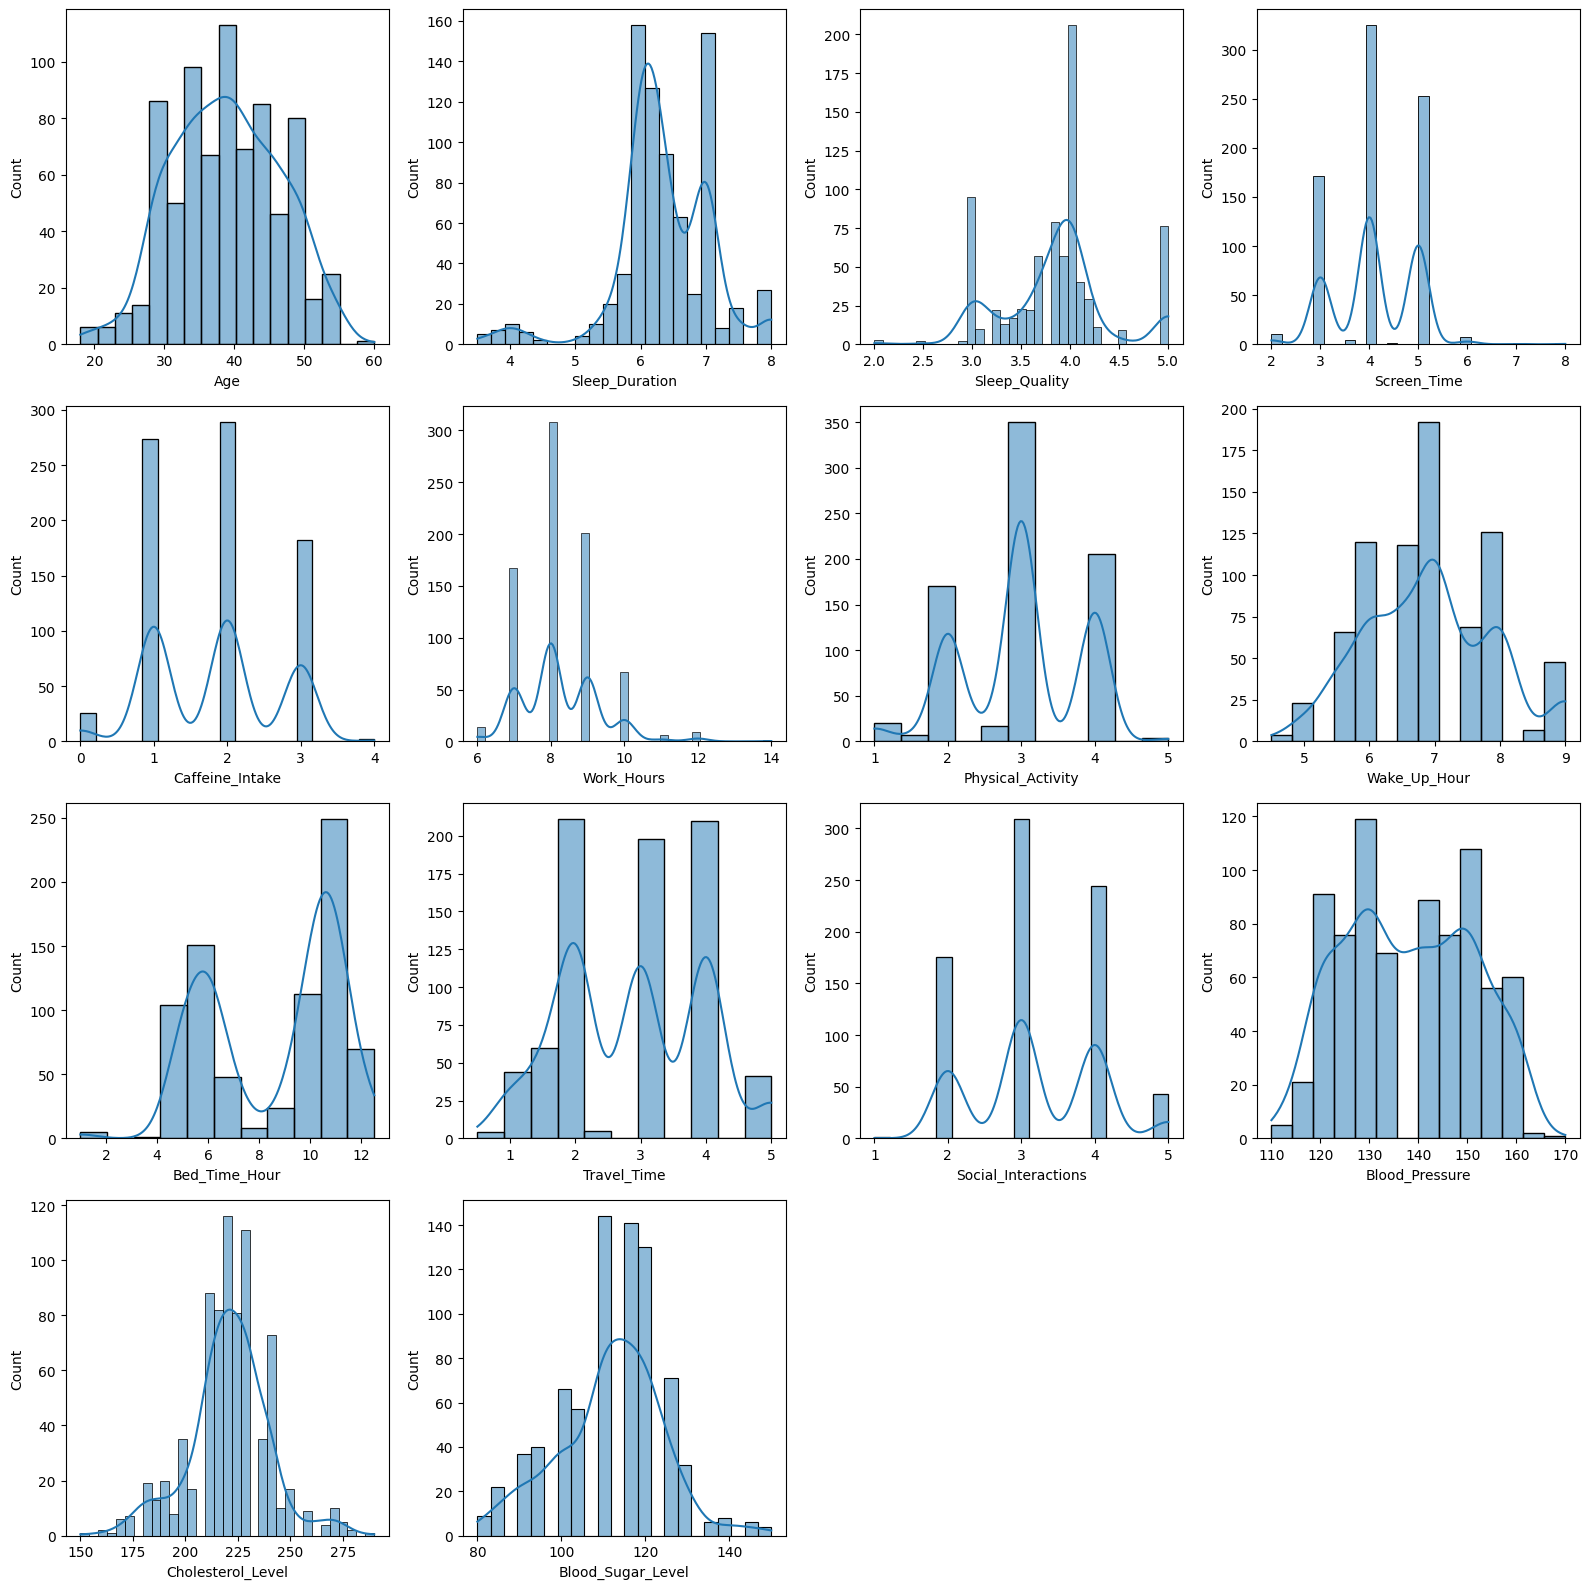

In [63]:
plt.figure(figsize=(16,16))
def plotting(var,num):
    plt.subplot(4,4,num)
    sns.histplot(df[var],kde = True)

plotting('Age',1)
plotting('Sleep_Duration',2)
plotting('Sleep_Quality',3)
plotting('Screen_Time',4)
plotting('Caffeine_Intake',5)
plotting('Work_Hours',6)
plotting('Physical_Activity',7)
plotting('Wake_Up_Hour',8)
plotting('Bed_Time_Hour',9)
plotting('Travel_Time',10)
plotting('Social_Interactions',11)
plotting('Blood_Pressure',12)
plotting('Cholesterol_Level',13)
plotting('Blood_Sugar_Level',14)

plt.tight_layout()

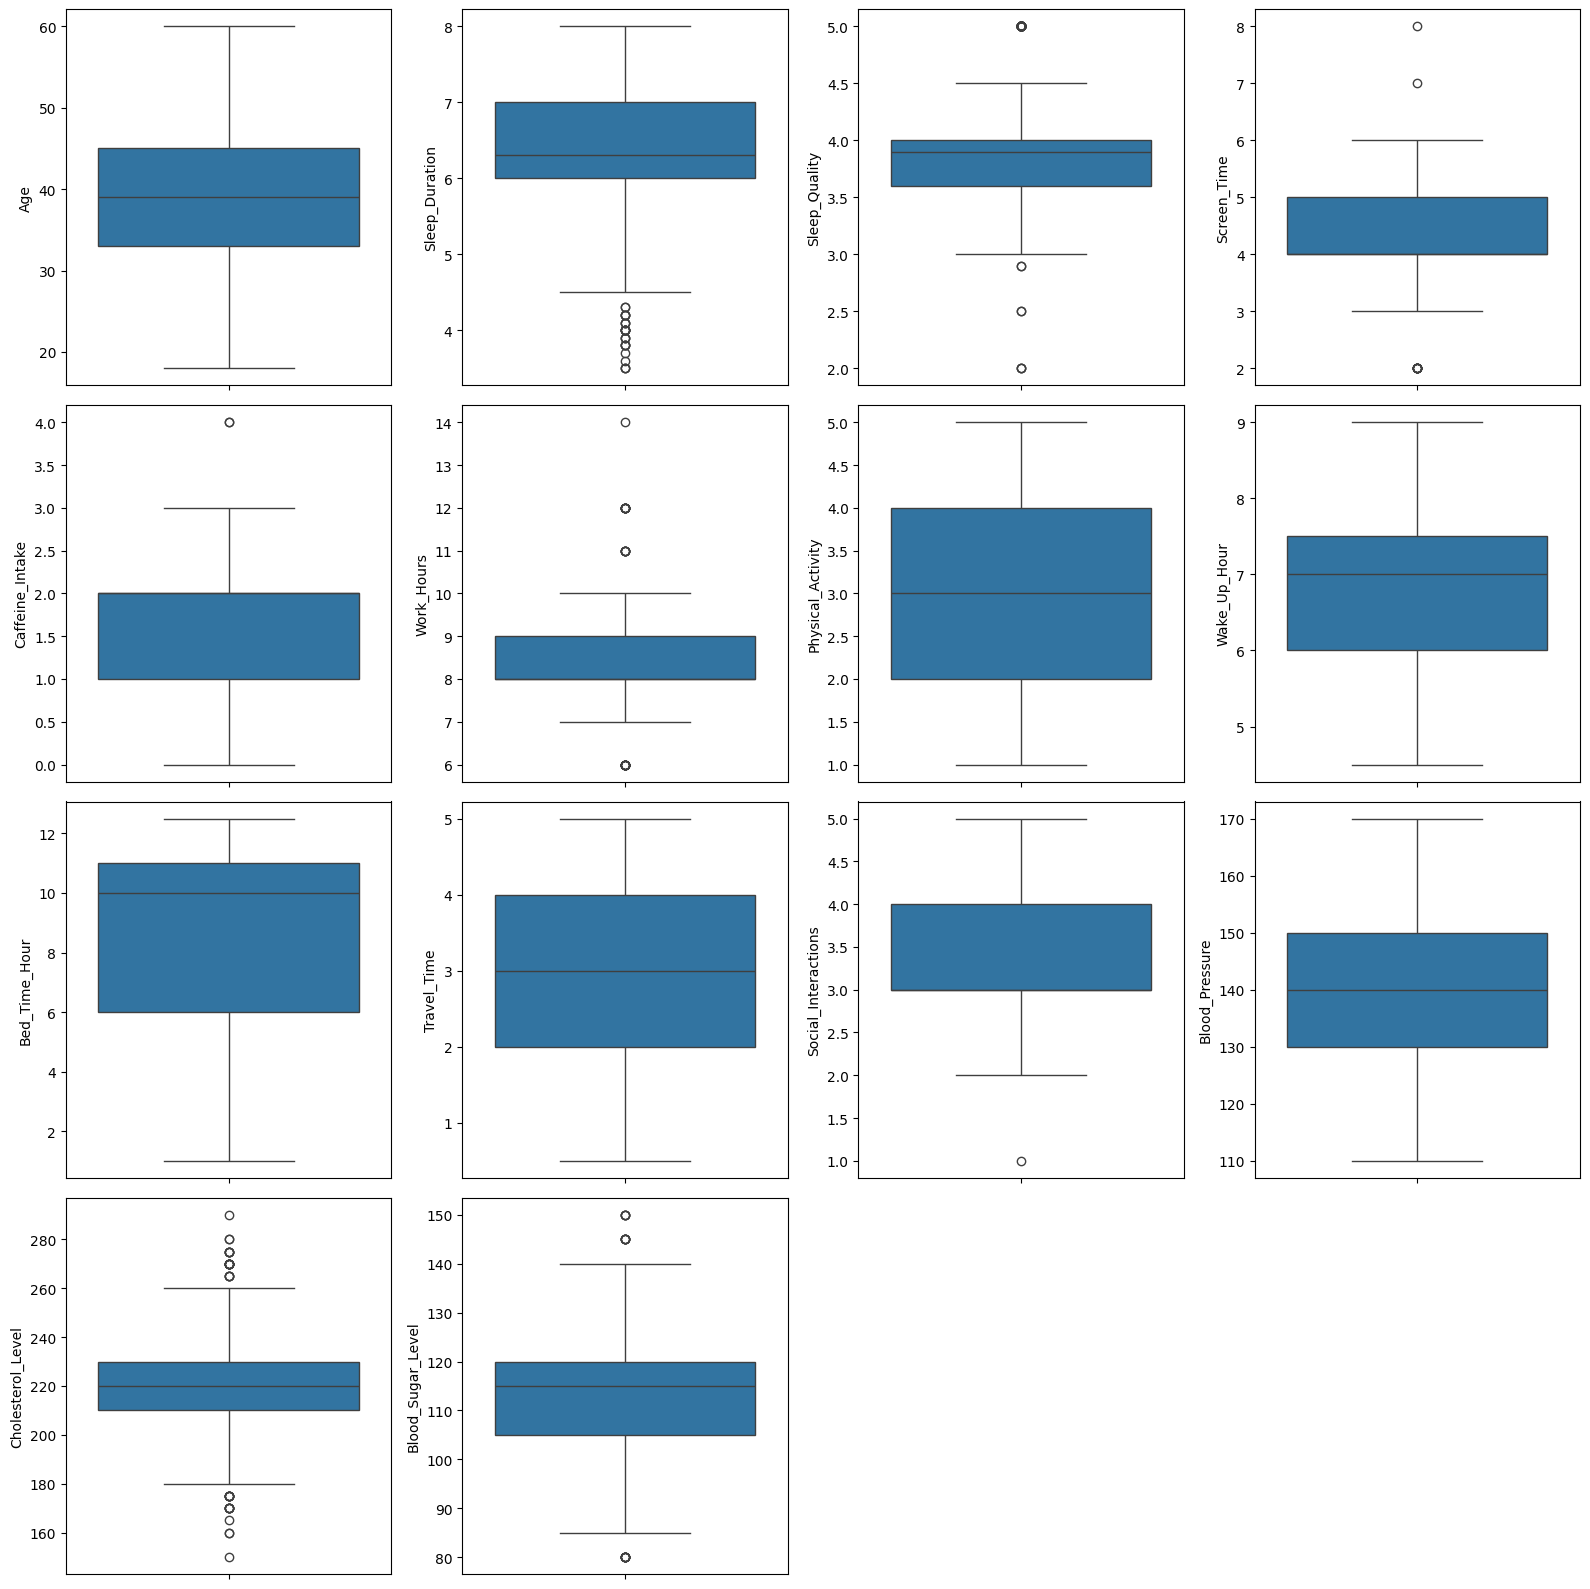

In [66]:
plt.figure(figsize=(16,16))
def plotting(var,num):
    plt.subplot(4,4,num)
    sns.boxplot(df[var])

plotting('Age',1)
plotting('Sleep_Duration',2)
plotting('Sleep_Quality',3)
plotting('Screen_Time',4)
plotting('Caffeine_Intake',5)
plotting('Work_Hours',6)
plotting('Physical_Activity',7)
plotting('Wake_Up_Hour',8)
plotting('Bed_Time_Hour',9)
plotting('Travel_Time',10)
plotting('Social_Interactions',11)
plotting('Blood_Pressure',12)
plotting('Cholesterol_Level',13)
plotting('Blood_Sugar_Level',14)

plt.tight_layout()

In [67]:
df.columns

Index(['Age', 'Gender', 'Occupation', 'Marital_Status', 'Sleep_Duration',
       'Sleep_Quality', 'Wake_Up_Time', 'Bed_Time', 'Physical_Activity',
       'Screen_Time', 'Caffeine_Intake', 'Alcohol_Intake', 'Smoking_Habit',
       'Work_Hours', 'Travel_Time', 'Social_Interactions',
       'Meditation_Practice', 'Exercise_Type', 'Blood_Pressure',
       'Cholesterol_Level', 'Blood_Sugar_Level', 'Stress_Detection',
       'Wake_Up_Hour', 'Bed_Time_Hour'],
      dtype='object')

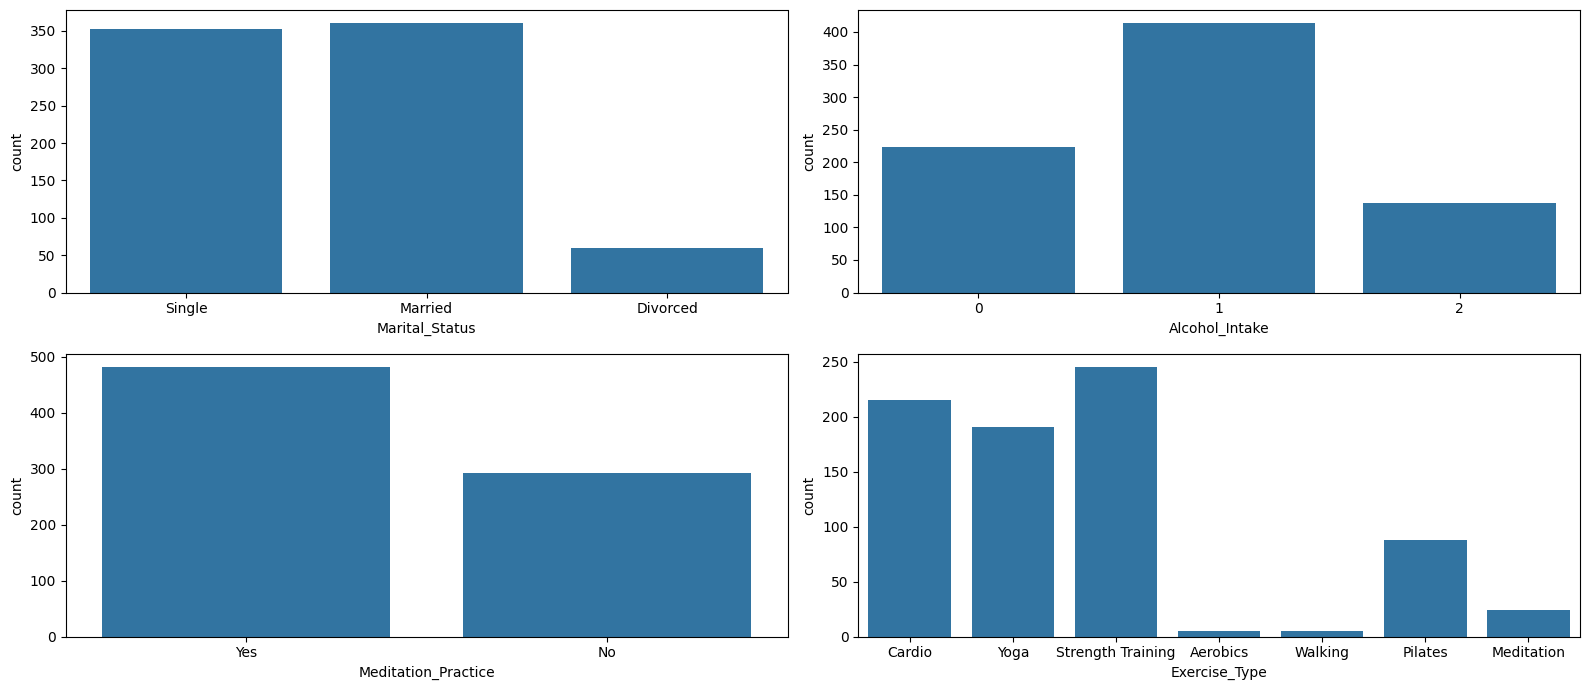

In [75]:
plt.figure(figsize=(16,7))
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.countplot( x=df[var],data=df )

plotting('Marital_Status',1)
plotting('Alcohol_Intake',2)
plotting('Meditation_Practice',3)
plotting('Exercise_Type',4)

plt.tight_layout()

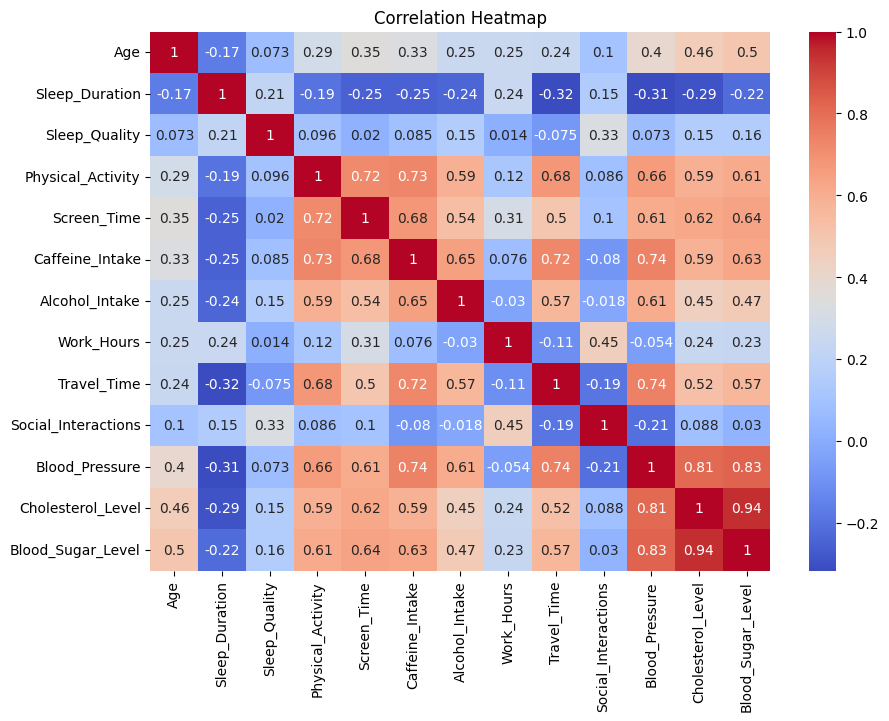

In [29]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

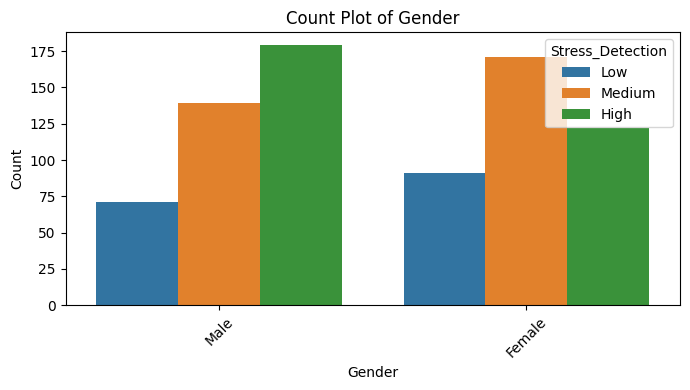

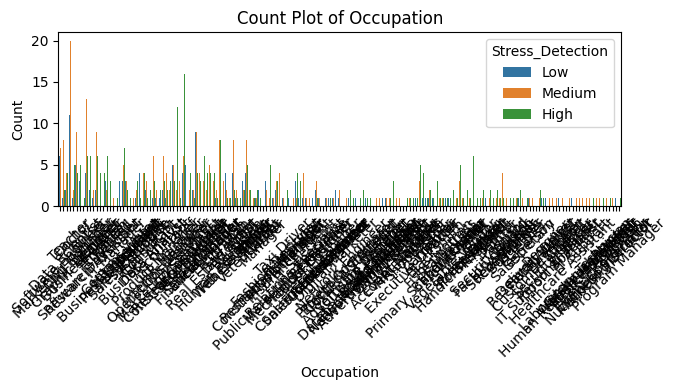

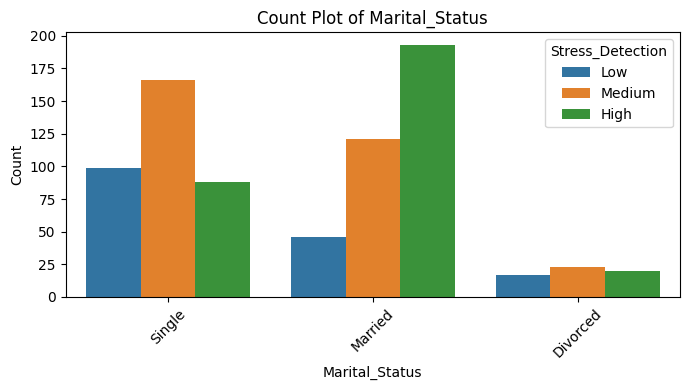

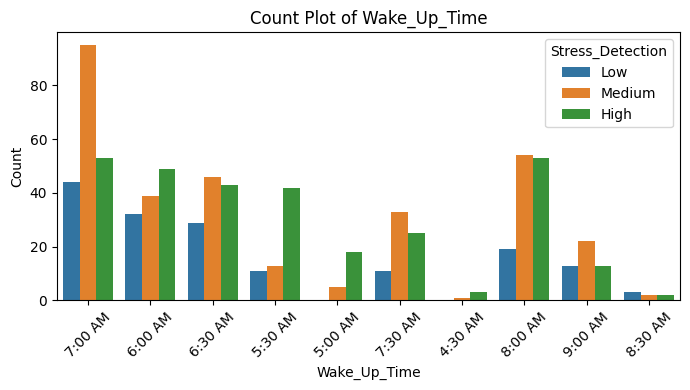

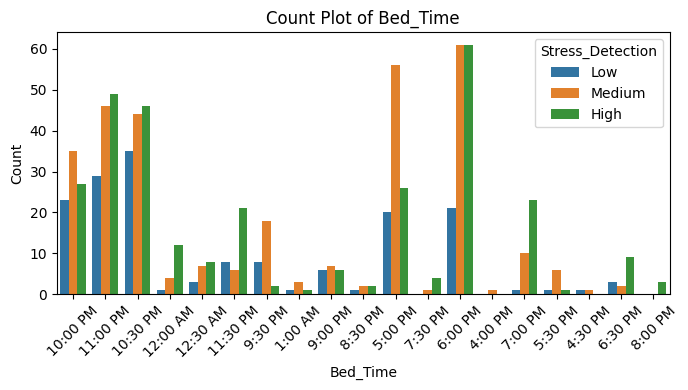

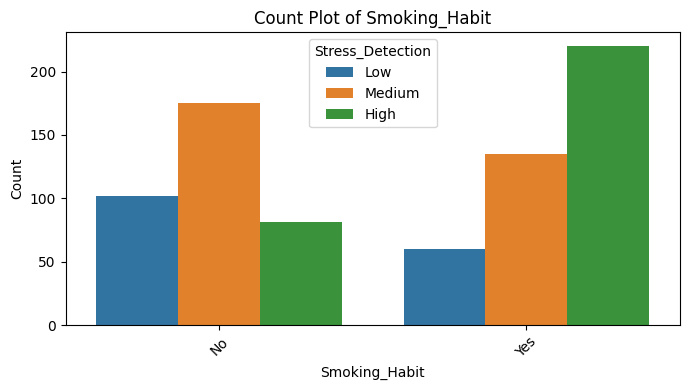

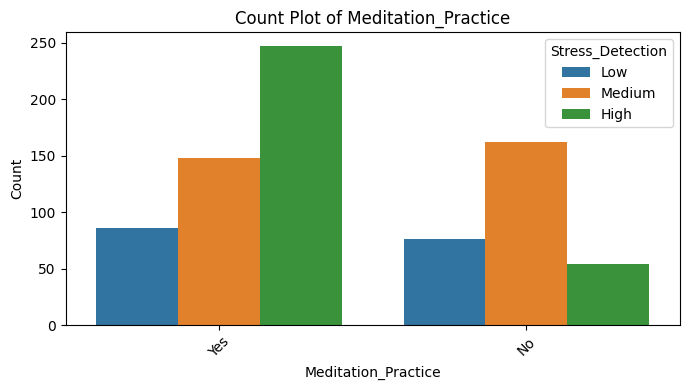

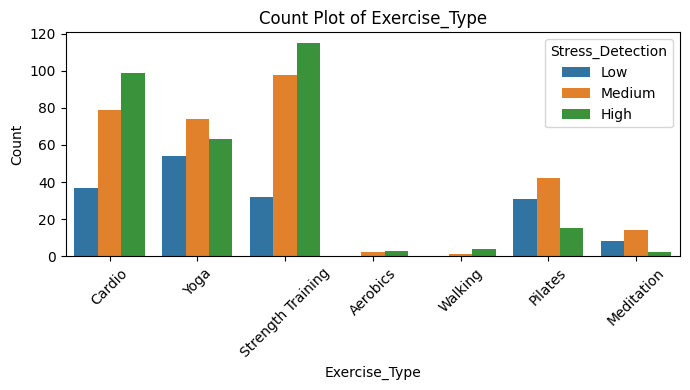

C:\Users\DELL\AppData\Local\Temp\ipykernel_21964\3276191624.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


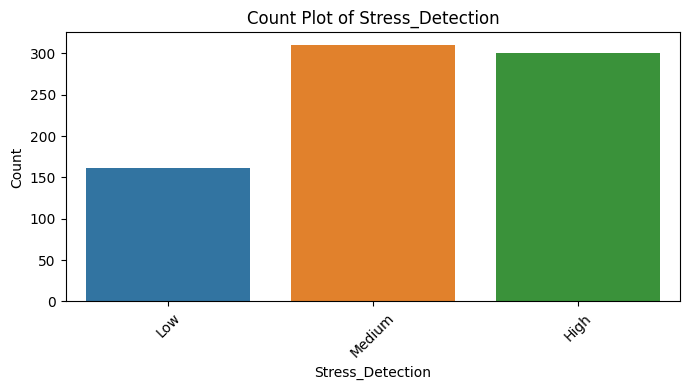

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(7, 4))
    
    # use hue only when target exists and column is not target
    if 'Stress_Detection' in df.columns and col != 'Stress_Detection':
        sns.countplot(
            x=df[col],
            hue=df['Stress_Detection'],
            palette='tab10'
        )
        plt.legend(title='Stress_Detection')
    else:
        sns.countplot(
            x=df[col],
            palette='tab10'
        )
    
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [76]:
df

,Age,Gender,Occupation,Marital_Status,Sleep_Duration,Sleep_Quality,Wake_Up_Time,Bed_Time,Physical_Activity,Screen_Time,...,Travel_Time,Social_Interactions,Meditation_Practice,Exercise_Type,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level,Stress_Detection,Wake_Up_Hour,Bed_Time_Hour
0,30,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,1.0,5,Yes,Cardio,120,180,90,Low,7.0,10.0
1,35,Female,Marketing Manager,Married,6.0,3.0,6:00 AM,11:00 PM,1.0,3.0,...,2.0,3,No,Yoga,110,160,80,Medium,6.0,11.0
2,40,Male,Data Scientist,Divorced,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,1.0,5,Yes,Strength Training,130,200,100,High,7.0,10.0
3,35,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,1.0,5,Yes,Cardio,120,180,90,Low,7.0,10.0
4,29,Female,Teacher,Single,8.0,5.0,6:30 AM,10:30 PM,3.0,2.0,...,1.0,4,Yes,Yoga,110,180,90,Low,6.5,10.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
768,40,Female,Teacher,Single,6.3,4.0,7:00 AM,5:00 PM,3.0,4.0,...,3.0,2,No,Yoga,155,235,120,Medium,7.0,5.0
769,42,Male,Writer,Married,6.0,3.7,8:00 AM,6:00 PM,3.0,4.0,...,3.0,2,No,Strength Training,150,230,115,Low,8.0,6.0
770,30,Female,Accountant,Single,6.1,3.8,7:00 AM,5:00 PM,4.0,5.0,...,3.0,2,Yes,Cardio,155,235,120,High,7.0,5.0
771,34,Male,Architect,Married,6.2,3.9,7:00 AM,6:00 PM,3.0,4.0,...,3.0,2,No,Strength Training,160,240,125,Medium,7.0,6.0


In [50]:
df['Sleep_Quality'].unique()

array([4. , 3. , 5. , 2. , 4.2, 4.5, 3.5, 4.3, 3.2, 3.8, 3.1, 3.7, 3.4,
       2.5, 2.9, 3.6, 3.9, 3.3, 4.1])

In [51]:
df.columns

Index(['Age', 'Gender', 'Occupation', 'Marital_Status', 'Sleep_Duration',
       'Sleep_Quality', 'Wake_Up_Time', 'Bed_Time', 'Physical_Activity',
       'Screen_Time', 'Caffeine_Intake', 'Alcohol_Intake', 'Smoking_Habit',
       'Work_Hours', 'Travel_Time', 'Social_Interactions',
       'Meditation_Practice', 'Exercise_Type', 'Blood_Pressure',
       'Cholesterol_Level', 'Blood_Sugar_Level', 'Stress_Detection'],
      dtype='object')